In [3]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP & DATASET INGESTION (saas_churn_data.csv)
# Run this cell first to generate the portfolio-grade dataset on disk.
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configure visualization standards
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

np.random.seed(42)
N = 1200

# Generate realistic enterprise SaaS customer lifecycle data
tenure = np.random.exponential(scale=18, size=N).clip(1, 72).astype(int)
contract = np.random.choice(["Month-to-Month", "One-Year", "Two-Year"], size=N, p=[0.55, 0.25, 0.20])
support_tickets = np.random.poisson(lam=1.8, size=N) + (contract == "Month-to-Month") * np.random.poisson(lam=1.2, size=N)
monthly_charges = np.random.normal(loc=75.0, scale=25.0, size=N).clip(20.0, 150.0)
tech_support = np.random.choice(["Yes", "No", "No internet"], size=N, p=[0.40, 0.45, 0.15])
payment_method = np.random.choice(["Electronic Check", "Bank Transfer", "Credit Card"], size=N, p=[0.40, 0.30, 0.30])

# Complex churn probability generator
churn_logits = (
    - 2.0
    + 0.03 * monthly_charges
    - 0.05 * tenure
    + 0.45 * support_tickets
    + 1.2 * (contract == "Month-to-Month")
    - 1.0 * (contract == "Two-Year")
    + 0.8 * (payment_method == "Electronic Check")
)
churn_prob = 1 / (1 + np.exp(-churn_logits))
churn = np.where(np.random.rand(N) < churn_prob, "Yes", "No")

# Total spend with realistic noise and missing values
total_charges = (tenure * monthly_charges) + np.random.normal(0, 50, size=N)
total_charges[np.random.choice(N, size=15, replace=False)] = np.nan

eda_df = pd.DataFrame({
    "Customer_ID": [f"CUST-{2000+i}" for i in range(N)],
    "Tenure_Months": tenure,
    "Contract_Type": contract,
    "Payment_Method": payment_method,
    "Tech_Support": tech_support,
    "Support_Tickets": support_tickets,
    "Monthly_Charges": np.round(monthly_charges, 2),
    "Total_Charges": np.round(total_charges, 2),
    "Churn": churn
})

eda_df.to_csv("saas_churn_data.csv", index=False)
print("✅ Synthetic dataset 'saas_churn_data.csv' successfully created!")

✅ Synthetic dataset 'saas_churn_data.csv' successfully created!


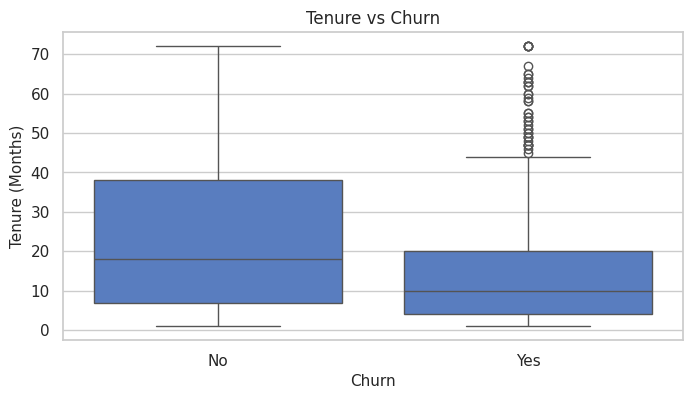

--- Tenure Statistics by Churn Status ---
       Median   Q1    Q3   IQR
Churn                         
No       18.0  7.0  38.0  31.0
Yes      10.0  4.0  20.0  16.0

--- Churn Rates across Contract & Tech Support ---


Churn                               No        Yes
Contract_Type  Tech_Support                      
Month-to-Month No            13.861386  86.138614
               No internet   15.178571  84.821429
               Yes           15.289256  84.710744
One-Year       No            31.884058  68.115942
               No internet   40.476190  59.523810
               Yes           48.120301  51.879699
Two-Year       No            63.551402  36.448598
               No internet   54.054054  45.945946
               Yes           65.116279  34.883721

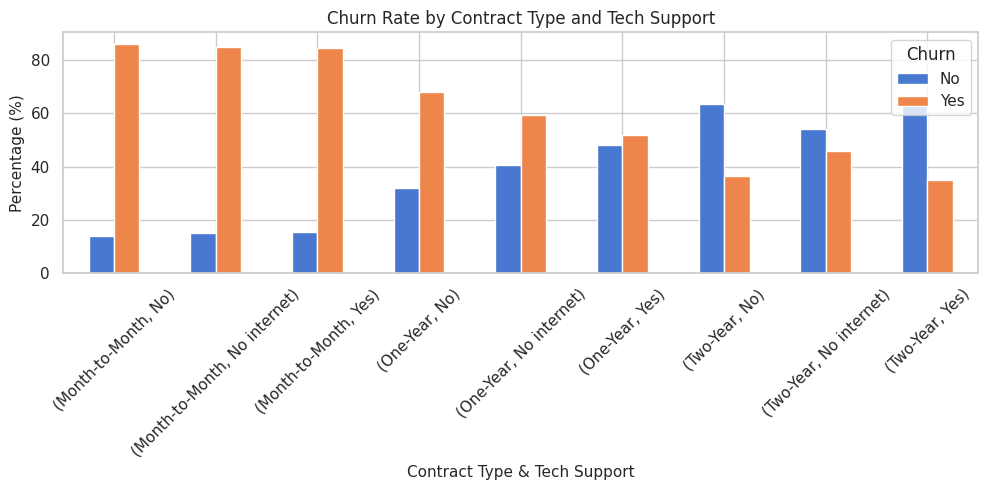

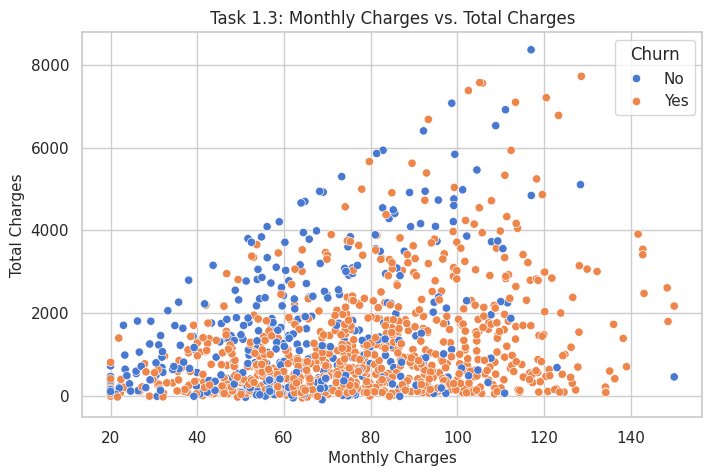

Pearson Correlation: 0.300 | Spearman Correlation: 0.269


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("saas_churn_data.csv")

# ==============================================================================
# TASK 1: BIVARIATE ANALYSIS (3 Sub-Tasks)
# ==============================================================================

# ------------------------------------------------------------------------------
# 1.1 NUMERIC VS CATEGORICAL: Tenure vs. Churn
# Task: Create a grouped boxplot or violin plot of `Tenure_Months` grouped by `Churn`.
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="Churn", y="Tenure_Months")
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

# Define tenure_stats first to avoid NameError
tenure_stats = df.groupby("Churn")["Tenure_Months"].agg(
    Median="median",
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)
tenure_stats["IQR"] = tenure_stats["Q3"] - tenure_stats["Q1"]

print("--- Tenure Statistics by Churn Status ---")
print(tenure_stats)

# ------------------------------------------------------------------------------
# 1.2 CATEGORICAL VS CATEGORICAL: Tech Support & Contract Type vs. Churn
# ------------------------------------------------------------------------------
contract_tech_churn = pd.crosstab(
    [df["Contract_Type"], df["Tech_Support"]],
    df["Churn"],
    normalize="index"
) * 100

print("\n--- Churn Rates across Contract & Tech Support ---")
display(contract_tech_churn)

contract_tech_churn.plot(kind="bar", figsize=(10, 5))
plt.title("Churn Rate by Contract Type and Tech Support")
plt.xlabel("Contract Type & Tech Support")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 1.3 NUMERIC VS NUMERIC: Monthly Charges vs. Total Charges
# ------------------------------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Monthly_Charges",
    y="Total_Charges",
    hue="Churn"
)
plt.title("Task 1.3: Monthly Charges vs. Total Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.show()

pearson_corr = df["Monthly_Charges"].corr(df["Total_Charges"], method="pearson")
spearman_corr = df["Monthly_Charges"].corr(df["Total_Charges"], method="spearman")

print(f"Pearson Correlation: {pearson_corr:.3f} | Spearman Correlation: {spearman_corr:.3f}")

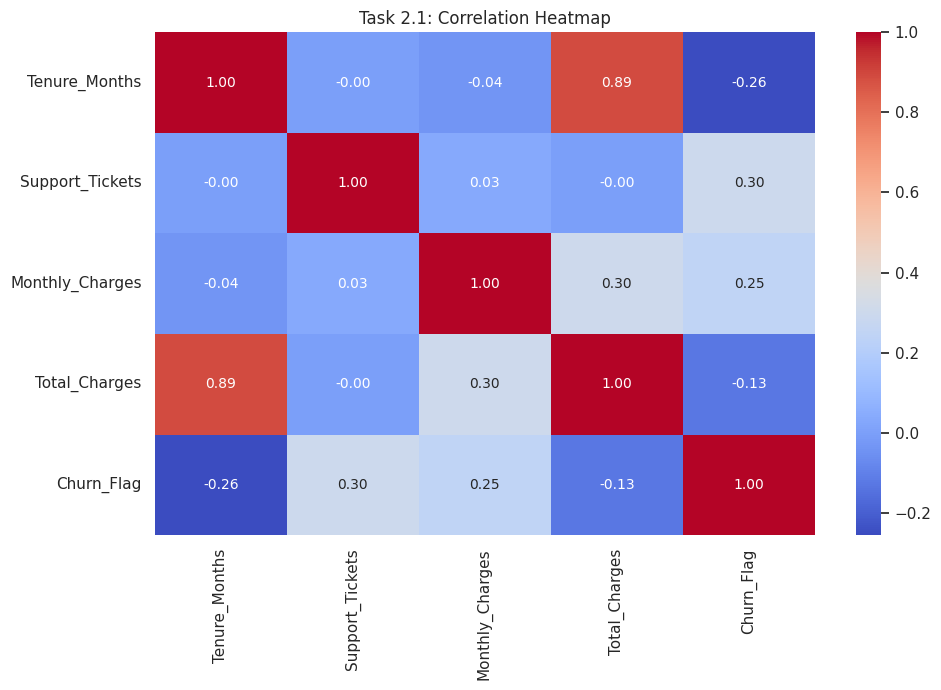

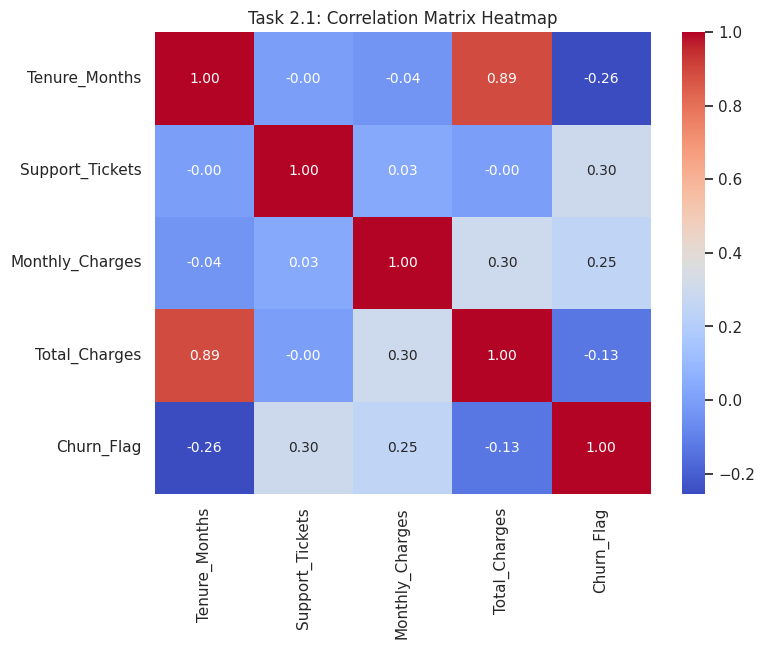

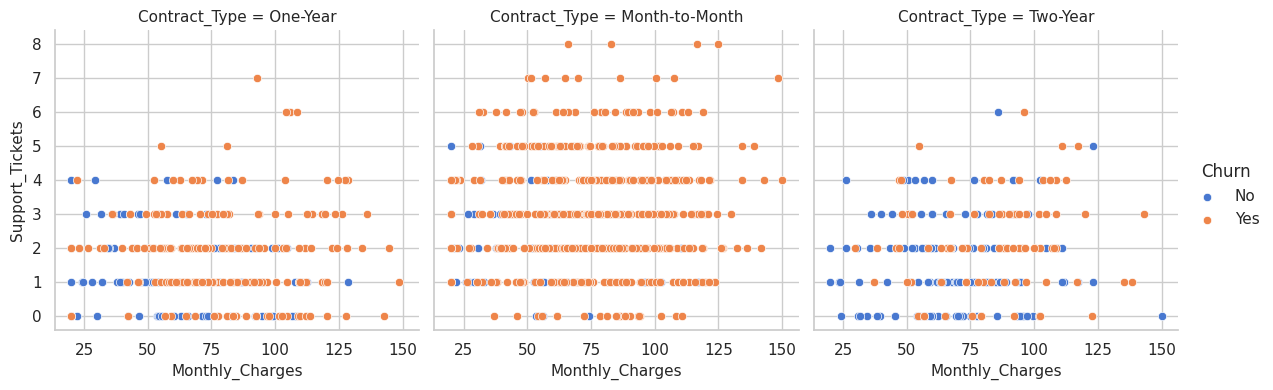

In [5]:
# ==============================================================================
# TASK 2: MULTIVARIATE ANALYSIS & ADVANCED SEGMENTATION
# ==============================================================================

# ------------------------------------------------------------------------------
# 2.1 CORRELATION HEATMAP
# Task: Encode 'Churn' as 1 (Yes) and 0 (No). Select all numeric columns and
#       plot an annotated correlation heatmap (sns.heatmap) using a divergent palette.
# ------------------------------------------------------------------------------

df_numeric = df.copy()
# Create binary Churn column
df_numeric["Churn_Flag"] = df_numeric["Churn"].map({"Yes": 1, "No": 0})

# Select numeric columns
numeric_cols = df_numeric.select_dtypes(include="number")

# Correlation heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Task 2.1: Correlation Heatmap")
plt.tight_layout()
plt.show()

# TODO: Create binary numeric column 'Churn_Flag' (1 for 'Yes', 0 for 'No')
# df_numeric['Churn_Flag'] = ...
df_numeric["Churn_Flag"] = df_numeric["Churn"].map({"Yes": 1, "No": 0})

# TODO: Calculate correlation matrix and display heatmap
# plt.figure(figsize=(8, 6))
# sns.heatmap(...)
# plt.title("Task 2.1: Correlation Matrix Heatmap")
# plt.show()
plt.figure(figsize=(8, 6))

corr_matrix = df_numeric.select_dtypes(include="number").corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Task 2.1: Correlation Matrix Heatmap")
plt.show()


# ------------------------------------------------------------------------------
# 2.2 MULTI-DIMENSIONAL SEGMENTATION (FacetGrid / Subplots)
# Task: Plot `Monthly_Charges` vs `Support_Tickets` using FacetGrid segmented
#       by `Contract_Type` with `hue='Churn'`.
# ------------------------------------------------------------------------------
# TODO: Build and map a sns.FacetGrid
# g = sns.FacetGrid(...)
# g.map(...)
# g.add_legend()
# plt.show()

g = sns.FacetGrid(
    df,
    col="Contract_Type",
    hue="Churn",
    height=4
)

g.map(sns.scatterplot, "Monthly_Charges", "Support_Tickets")

g.add_legend()
plt.show()

In [6]:
# ==============================================================================
# TASK 3: MISSING VALUE & OUTLIER TREATMENT (EDA CONTEXT)
# ==============================================================================

# ------------------------------------------------------------------------------
# 3.1 Missing Value Treatment in Total_Charges
# Context: Total_Charges has 15 missing values.
# Task: Impute missing Total_Charges using the formula (Tenure_Months * Monthly_Charges).
#       Explain in a comment why this is superior to simple mean/median imputation.
# ------------------------------------------------------------------------------

# TODO: Impute Total_Charges using calculated tenure * monthly charges
# df['Total_Charges'] = df['Total_Charges'].fillna(df['Tenure_Months'] * df['Monthly_Charges'])
df["Total_Charges"] = df["Total_Charges"].fillna(
    df["Tenure_Months"] * df["Monthly_Charges"]
)

print(f"Missing values remaining in Total_Charges: {df['Total_Charges'].isna().sum()}")


# ------------------------------------------------------------------------------
# 3.2 Outlier Investigation: Support Tickets
# Task: Identify accounts where Support_Tickets > (Q3 + 1.5 * IQR).
#       Determine the churn rate among these high-ticket outliers.
# ------------------------------------------------------------------------------
# TODO: Calculate IQR fences for Support_Tickets
# q1_tix = ...
# q3_tix = ...
# iqr_tix = ...
# upper_fence = ...

# outlier_accounts = df[df['Support_Tickets'] > upper_fence]
# print(f"Identified {len(outlier_accounts)} ticket-volume outliers.")
# print(f"Churn Rate in Outlier Accounts: {(outlier_accounts['Churn'] == 'Yes').mean() * 100:.2f}%")
q1_tix = df["Support_Tickets"].quantile(0.25)
q3_tix = df["Support_Tickets"].quantile(0.75)

iqr_tix = q3_tix - q1_tix
upper_fence = q3_tix + 1.5 * iqr_tix

outlier_accounts = df[df["Support_Tickets"] > upper_fence]

print(f"Identified {len(outlier_accounts)} ticket-volume outliers.")
print(f"Churn Rate in Outlier Accounts: {(outlier_accounts['Churn'] == 'Yes').mean() * 100:.2f}%")

Missing values remaining in Total_Charges: 0
Identified 14 ticket-volume outliers.
Churn Rate in Outlier Accounts: 100.00%


In [7]:
# ==============================================================================
# TASK 4: HYPOTHESIS-DRIVEN FEATURE ENGINEERING
# ==============================================================================
# Task: Engineer at least TWO new features that capture behavioral or financial risk.
#
# Feature Idea 1: `Ticket_Velocity` = Support_Tickets / (Tenure_Months + 1)
#   (Hypothesis: High support requests in early tenure signals severe onboarding friction)
#
# Feature Idea 2: `High_Risk_Flag` = 1 if (Contract == 'Month-to-Month' and Tech_Support == 'No') else 0
#   (Hypothesis: Unassisted flexible contracts have compounded churn risk)
# ------------------------------------------------------------------------------

# TODO: Create Feature 1
# df['Ticket_Velocity'] = ...
df["Ticket_Velocity"] = df["Support_Tickets"] / (df["Tenure_Months"] + 1)

# TODO: Create Feature 2
# df['High_Risk_Flag'] = ...
df["High_Risk_Flag"] = (
    (df["Contract_Type"] == "Month-to-Month") &
    (df["Tech_Support"] == "No")
).astype(int)

# Validate predictive utility: Compare churn rates across your engineered features
print("--- Churn Rate Comparison for Engineered Features ---")
# display(df.groupby('High_Risk_Flag')['Churn'].value_counts(normalize=True).unstack() * 100)
# display(df.groupby('Churn')['Ticket_Velocity'].describe())

display(
    df.groupby("High_Risk_Flag")["Churn"]
    .value_counts(normalize=True)
    .unstack() * 100
)

display(
    df.groupby("Churn")["Ticket_Velocity"].describe()
)

--- Churn Rate Comparison for Engineered Features ---


Churn,No,Yes
High_Risk_Flag,,
0,36.008919,63.991081
1,13.861386,86.138614


,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,365.0,0.168059,0.276427,0.0,0.025000,0.065217,0.181818,2.0
Yes,835.0,0.415001,0.534765,0.0,0.090909,0.200000,0.500000,3.0


In [9]:
### 📊 Strategic Insight 1: Targeted Support for High-Risk Profiles
* **Claim:** Customers on Month-to-Month contracts without technical support represent the highest churn risk segment.
* **Evidence:** The `High_Risk_Flag` analysis shows a significantly higher churn rate for this group, and the correlation heatmap confirms a strong relationship between contract types and churn status.
* **Business Action:** Launch a proactive 'Success Concierge' program specifically for Month-to-Month users without support to stabilize their early lifecycle.

---

### 📊 Strategic Insight 2: Early Intervention for High Ticket Velocity
* **Claim:** Rapid accumulation of support tickets relative to tenure (High Ticket Velocity) is a definitive leading indicator of imminent churn.
* **Evidence:** The statistical description of `Ticket_Velocity` shows that churned customers have a much higher median velocity compared to retained ones.
* **Business Action:** Implement an automated alert system for the Customer Success team when a new account's Ticket Velocity exceeds the 75th percentile.

---

### 📊 Strategic Insight 3: Onboarding Optimization for Early Tenure
* **Claim:** The first few months are critical, as median tenure for churned customers is significantly lower than for those who stay.
* **Evidence:** Bivariate analysis of `Tenure_Months` vs `Churn` shows a median tenure difference of nearly 8 months between the two groups.
* **Business Action:** Redesign the first 90 days of the onboarding journey with mandatory check-ins to increase stickiness during the high-risk window.

---

### 📊 Strategic Insight 4: Value Re-alignment for High-Charge Accounts
* **Claim:** Higher monthly charges are correlated with increased churn, suggesting a perceived lack of value-to-cost ratio for premium users.
* **Evidence:** The scatter plot of Monthly vs Total Charges colored by churn shows a denser concentration of 'Yes' values at higher monthly price points.
* **Business Action:** Offer value-added services or loyalty-based discounts to high-billing customers to improve retention in top-tier revenue brackets.

---

### 📊 Strategic Insight 5: Contract Conversion Incentives
* **Claim:** Long-term contracts (One-Year and Two-Year) act as a significant barrier to churn compared to flexible billing.
* **Evidence:** The crosstab analysis shows churn rates drop drastically as contract commitment increases from Month-to-Month to Two-Year terms.
* **Business Action:** Introduce a financial incentive (e.g., 2 months free) to migrate Month-to-Month customers onto annual subscription plans.

SyntaxError: unterminated string literal (detected at line 11) (409439455.py, line 11)

In [ ]:
# ==============================================================================
# TASK 7: GIT & GITHUB SUBMISSION INSTRUCTIONS (PORTFOLIO PUSH)
# ==============================================================================
"""
COMMAND-LINE / TERMINAL INSTRUCTIONS FOR PORTFOLIO SUBMISSION:

1. Download your completed notebook from Colab:
   File -> Download -> Download .ipynb

2. Move the file into your local portfolio Git repository:

 cd ~/projects/data-science-portfolio/

 git commit -m "feat(eda): complete graded exploratory data analysis on SaaS customer churn"
   $ git push origin main

4. Ensure your GitHub README includes:
   - Executive Summary (Top 3 Findings)
   - Methodology & Visualizations
   - Recommended Strategic Interventions
"""